In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn tensorflow-cpu jupyter

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

In [4]:

df = pd.read_csv('C:\\Users\\HP\\Documents\\Fraud Detection\\creditcard.csv')
df.head(12)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [5]:
df.shape

(284807, 31)

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
print(df.isnull().sum())  # Check for missing values
print(df.dtypes)  # Verify data types

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [9]:
# Data Preprocessing
# Drop Time column as it's not directly useful for fraud detection
df = df.drop(['Time'], axis=1)

# Scale Amount
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

# Check class distribution
print('Class distribution:')
print(df['Class'].value_counts(normalize=True))

Class distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


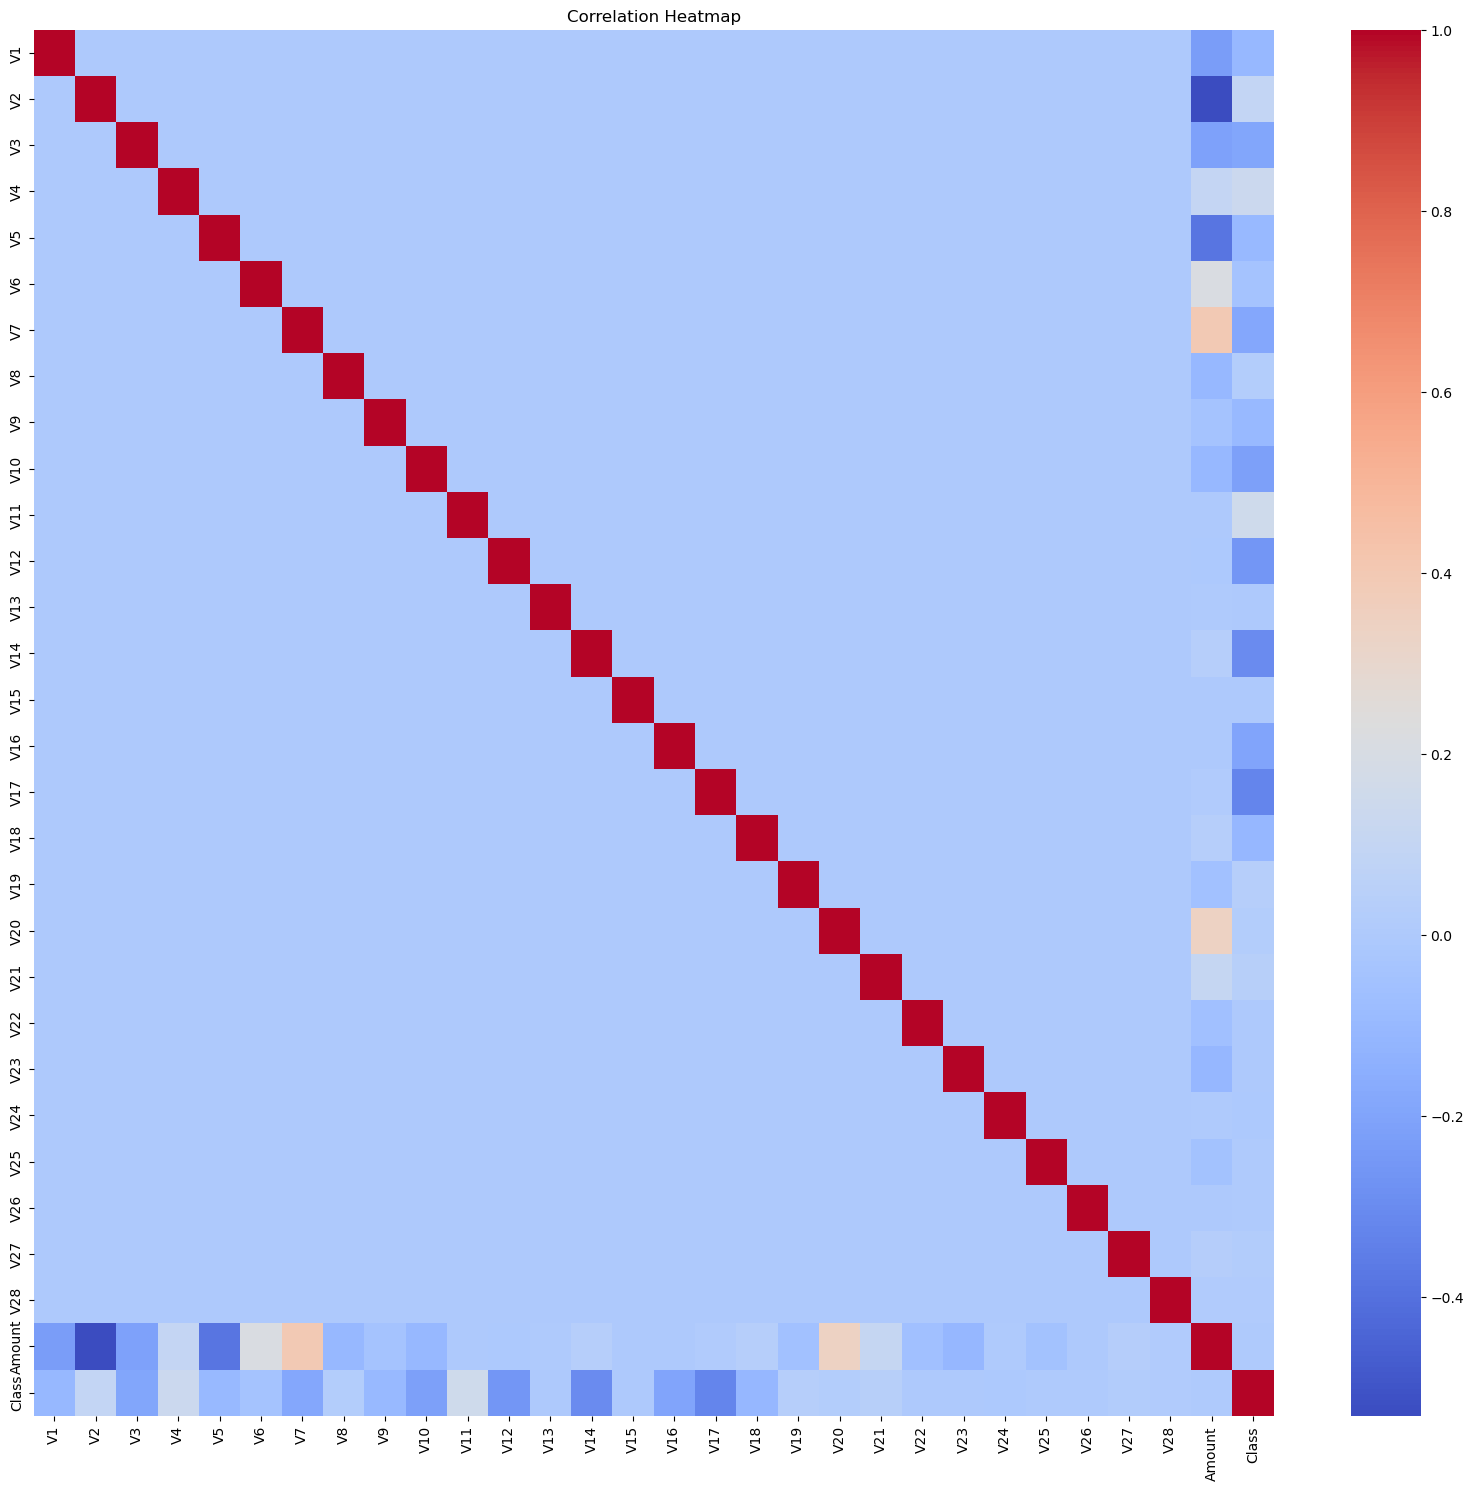

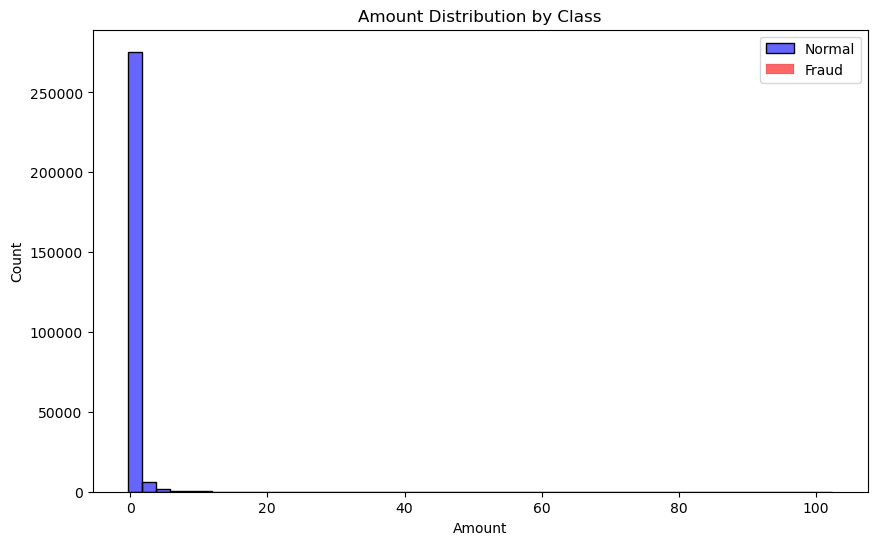

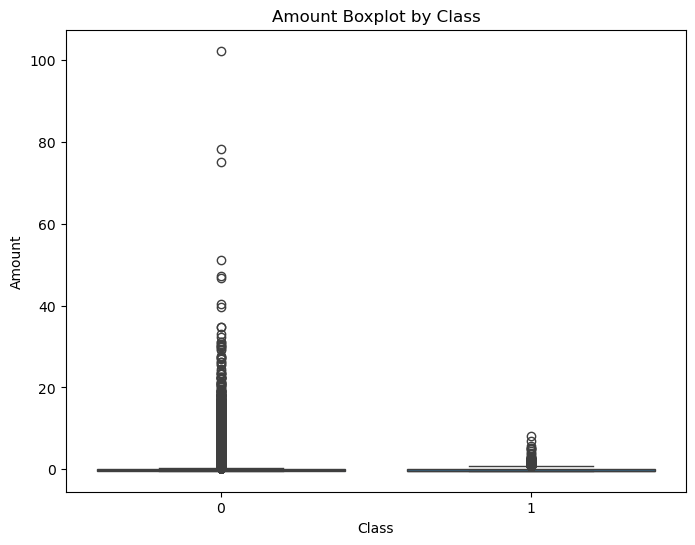

In [25]:
# EDA
# Correlation heatmap
plt.figure(figsize=(20,18))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Distribution of Amount
plt.figure(figsize=(10,6))
sns.histplot(df[df['Class']==0]['Amount'], bins=50, color='blue', label='Normal', alpha=0.6)
sns.histplot(df[df['Class']==1]['Amount'], bins=50, color='red', label='Fraud', alpha=0.6)
plt.legend()
plt.title('Amount Distribution by Class')
plt.show()

# Boxplot for Amount
plt.figure(figsize=(8,6))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Amount Boxplot by Class')
plt.show()

In [26]:
# Split data
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handle imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Original training class distribution:')
print(y_train.value_counts())
print('After SMOTE:')
print(pd.Series(y_train_sm).value_counts())

Original training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [12]:
# ML Models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:,1]
    
    print(f'\n{name}:')
    print(classification_report(y_test, y_pred))
    print(f'AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}')
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'auc': roc_auc_score(y_test, y_pred_proba)
    }


Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

AUC-ROC: 0.9700

Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9731

XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.87      0.77        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     

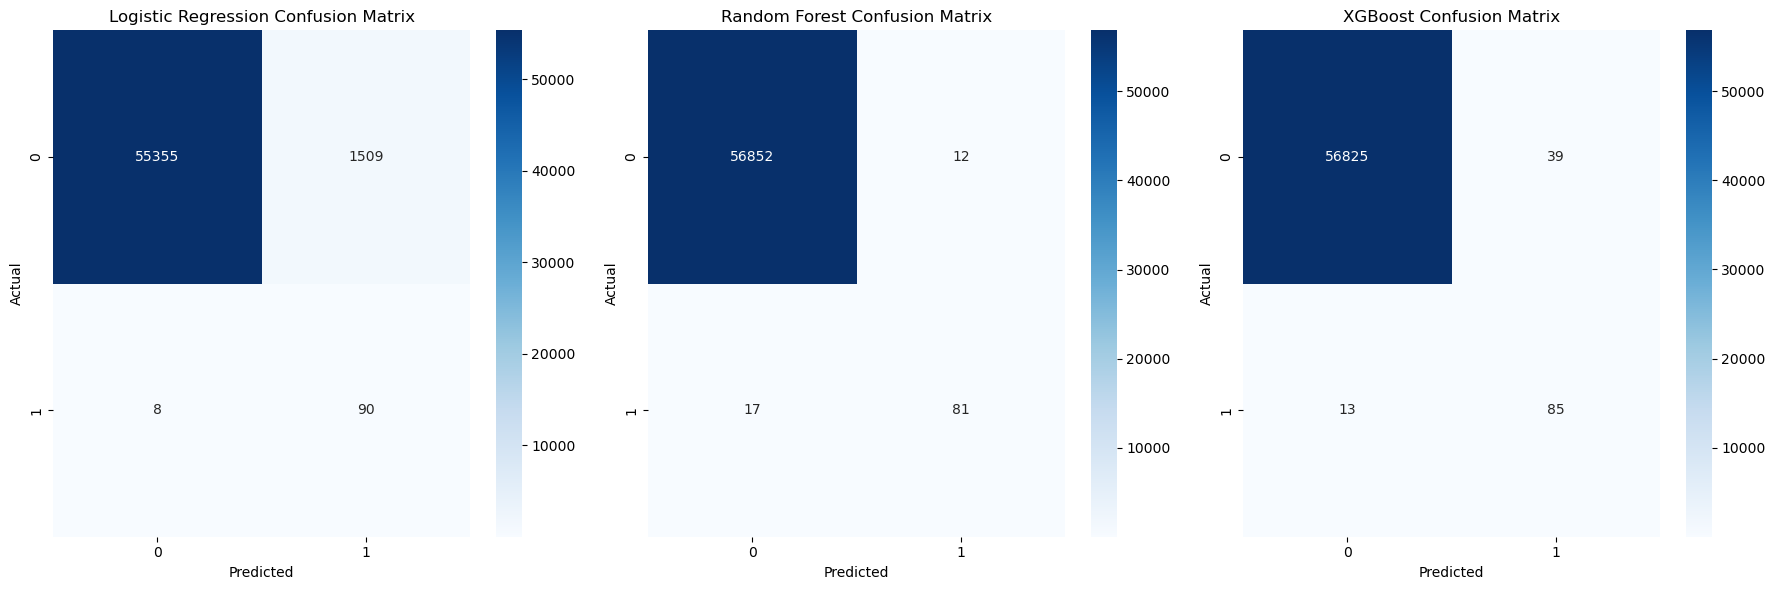

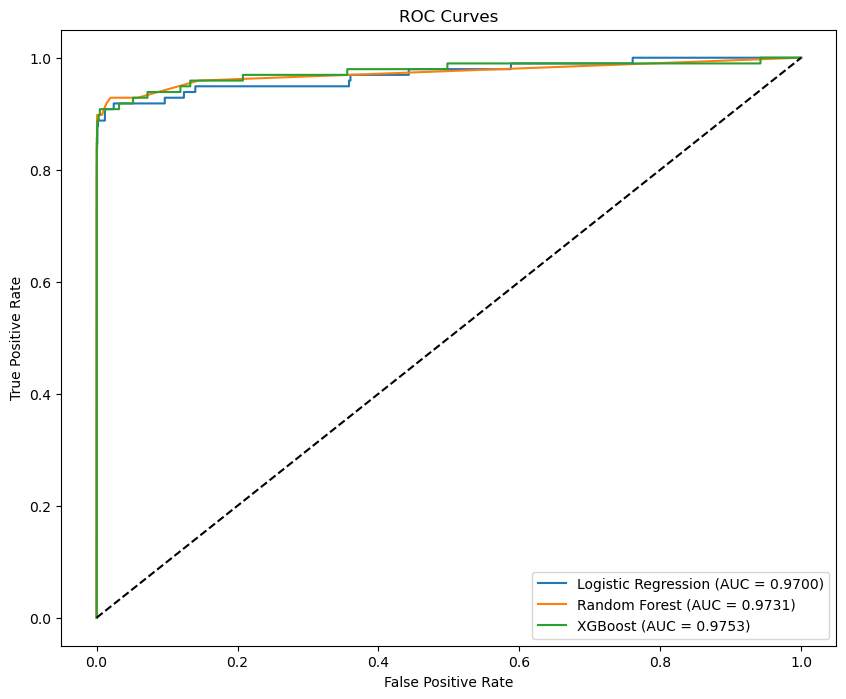

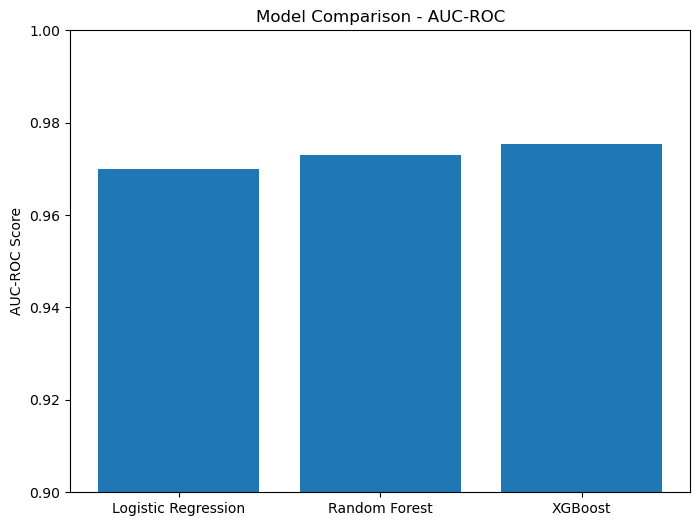

In [13]:
# Compare Models
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(10,8))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {res["auc"]:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

# AUC Scores
auc_scores = {name: res['auc'] for name, res in results.items()}
plt.figure(figsize=(8,6))
plt.bar(auc_scores.keys(), auc_scores.values())
plt.ylabel('AUC-ROC Score')
plt.title('Model Comparison - AUC-ROC')
plt.ylim(0.9, 1.0)  # Assuming high scores
plt.show()

In [14]:
# Save the Best Model
best_model_name = max(auc_scores, key=auc_scores.get)
best_model = results[best_model_name]['model']
print(f'Best model: {best_model_name} with AUC: {auc_scores[best_model_name]:.4f}')

joblib.dump(best_model, 'best_fraud_model.pkl')
print('Best model saved as best_fraud_model.pkl')

Best model: XGBoost with AUC: 0.9753
Best model saved as best_fraud_model.pkl


## ✅ Next steps (what to do from here)

- **Hyperparameter tuning** (e.g., RandomizedSearchCV) to squeeze extra performance out of the best model.
- **Threshold tuning** using Precision-Recall curve to balance false positives vs false negatives.
- **Feature importance / explainability** to understand what drives fraud decisions.
- **Save a reusable inference pipeline** (preprocessing + model) so you can easily score new transactions.
- **Deploy**: Wrap the best model in a script or API (Flask/FastAPI) for production.

The following cells implement the first four items above in this notebook.

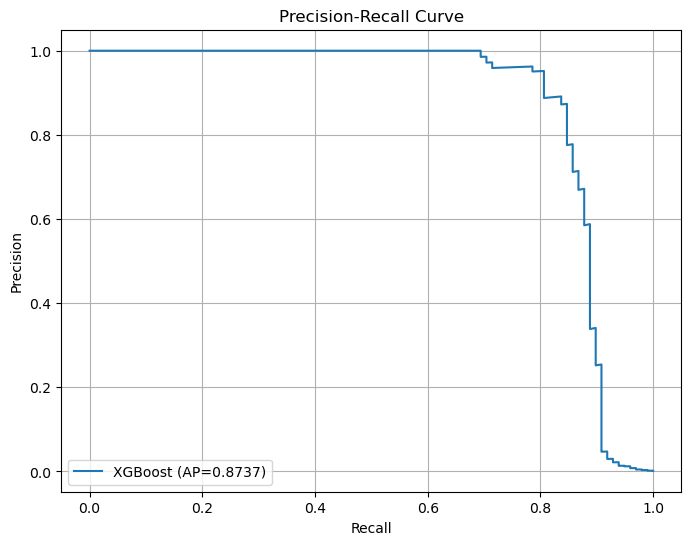

Best threshold by F1: 0.9742
Precision: 0.9518, Recall: 0.8061, F1: 0.8729

Classification report at best threshold:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.98      0.90      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [15]:
# Precision-Recall curve and threshold tuning (for the best model)
best_model = results[best_model_name]['model']
y_pred_proba_best = results[best_model_name]['y_pred_proba']

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_best)
avg_prec = average_precision_score(y_test, y_pred_proba_best)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'{best_model_name} (AP={avg_prec:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

# Find the threshold that gives the best F1 score (tradeoff)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-12)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f'Best threshold by F1: {best_threshold:.4f}')
print(f'Precision: {precision[best_idx]:.4f}, Recall: {recall[best_idx]:.4f}, F1: {f1_scores[best_idx]:.4f}')

# Apply threshold to produce predictions
y_pred_best_thresh = (y_pred_proba_best >= best_threshold).astype(int)
print('\nClassification report at best threshold:')
print(classification_report(y_test, y_pred_best_thresh))

In [16]:
# Hyperparameter tuning for XGBoost (RandomizedSearchCV)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train_sm, y_train_sm)
print('Best params:', search.best_params_)

best_xgb = search.best_estimator_

# Evaluate tuned model
y_pred = best_xgb.predict(X_test)
y_pred_proba = best_xgb.predict_proba(X_test)[:,1]
print('\nTuned XGBoost performance:')
print(classification_report(y_test, y_pred))
print(f'AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}')

# Update results dict if tuned model improved
tuned_auc = roc_auc_score(y_test, y_pred_proba)
if tuned_auc > auc_scores.get('XGBoost', 0):
    results['XGBoost Tuned'] = {
        'model': best_xgb,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'auc': tuned_auc
    }
    auc_scores['XGBoost Tuned'] = tuned_auc
    best_model_name = 'XGBoost Tuned'
    best_model = best_xgb
    print(f'Updated best model to tuned XGBoost with AUC: {tuned_auc:.4f}')
else:
    print('No improvement over original XGBoost.')


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Tuned XGBoost performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.67      0.88      0.76        98

    accuracy                           1.00     56962
   macro avg       0.83      0.94      0.88     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9758
Updated best model to tuned XGBoost with AUC: 0.9758


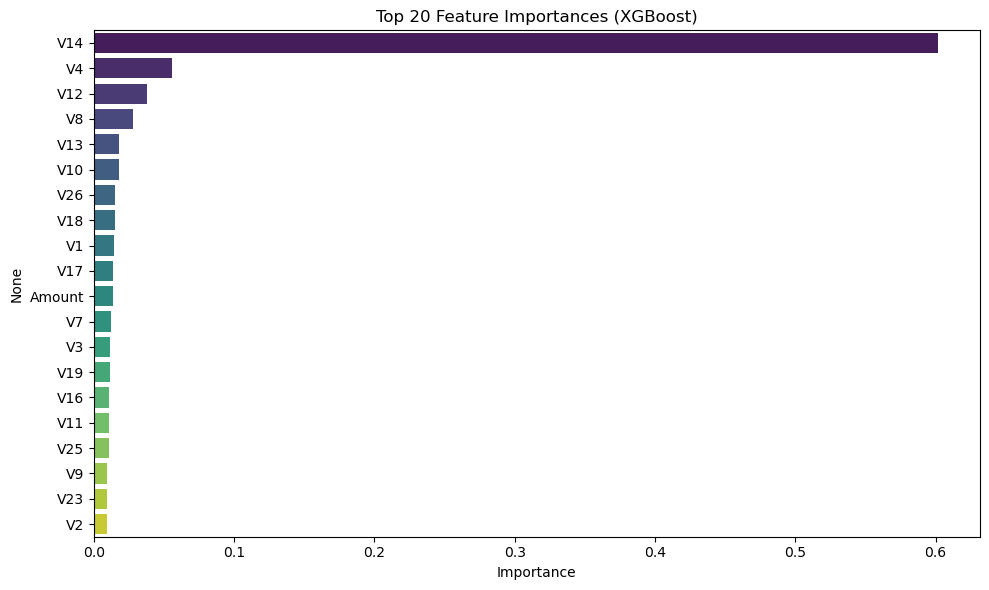

Saved inference pipeline to fraud_detection_pipeline.pkl
[0 0 0 0 0 0 0 0 0 0]
[4.6233305e-07 4.6891020e-07 3.3482755e-07 2.1193387e-08 3.0025085e-05
 3.4351299e-06 5.2287868e-07 3.6876477e-07 7.3508991e-06 3.1471588e-06]


In [17]:
# Feature importance (XGBoost)
try:
    importances = best_xgb.feature_importances_
    feature_names = X_train.columns
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    
    plt.figure(figsize=(10,6))
    sns.barplot(x=feat_imp.values[:20], y=feat_imp.index[:20], palette='viridis')
    plt.title('Top 20 Feature Importances (XGBoost)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Could not compute feature importances:', e)

# Save the preprocessing + model pipeline
from sklearn.pipeline import Pipeline as SklearnPipeline

pipeline = SklearnPipeline([
    ('scaler', scaler),
    ('model', best_xgb)
])

joblib.dump(pipeline, 'fraud_detection_pipeline.pkl')
print('Saved inference pipeline to fraud_detection_pipeline.pkl')

# Example: Loading and using the pipeline for prediction
# loaded_pipe = joblib.load('fraud_detection_pipeline.pkl')
# sample = X_test.iloc[:5]
# print(loaded_pipe.predict(sample))
# print(loaded_pipe.predict_proba(sample)[:,1])

# Example: Loading and using the pipeline for prediction
# # loaded_pipe = joblib.load('fraud_detection_pipeline.pkl')'best_fraud_model.pkl')
loaded_pipe = joblib.load('best_fraud_model.pkl')
sample = X_test.iloc[:10]
print(loaded_pipe.predict(sample))
print(loaded_pipe.predict_proba(sample)[:,1])

In [21]:
# Full inference function
def predict_fraud(transaction_data):
    """
    Predict fraud for a single transaction or batch of transactions.
    
    Args:
        transaction_data: dict or DataFrame with transaction features
                         Must include all features except 'Class' and 'Time'
                         Amount will be scaled automatically
    
    Returns:
        dict: {'prediction': 'fraud' or 'no_fraud', 'probability': float}
        or list of dicts for batch input
    """
    # Load the pipeline
    pipeline = joblib.load('best_fraud_model.pkl')
    
    # Convert to DataFrame if dict
    if isinstance(transaction_data, dict):
        df = pd.DataFrame([transaction_data])
    elif isinstance(transaction_data, pd.DataFrame):
        df = transaction_data.copy()
    else:
        raise ValueError("Input must be dict or DataFrame")
    
    # Ensure all required features are present (excluding Time and Class)
    required_features = [col for col in X_train.columns if col not in ['Time', 'Class']]
    missing_features = [f for f in required_features if f not in df.columns]
    if missing_features:
        raise ValueError(f"Missing features: {missing_features}")
    
    # Select only required features
    df = df[required_features]
    
    # Get predictions
    predictions = pipeline.predict(df)
    probabilities = pipeline.predict_proba(df)[:, 1]
    
    # Format results
    results = []
    for pred, prob in zip(predictions, probabilities):
        result = {
            'prediction': 'fraud' if pred == 1 else 'no_fraud',
            'probability': float(prob)
        }
        results.append(result)
    
    # Return single result for single input, list for batch
    return results[0] if len(results) == 1 else results

# Example usage
sample_transaction = X_test.iloc[0].to_dict()
result = predict_fraud(sample_transaction)
print("Sample prediction:", result)

Sample prediction: {'prediction': 'no_fraud', 'probability': 4.623330482900201e-07}


In [20]:
# Run FastAPI server from notebook
import subprocess
import sys

def start_fastapi():
    """Start the FastAPI server"""
    try:
        # Use the same Python executable as the notebook
        python_exe = sys.executable
        cmd = [python_exe, "-m", "uvicorn", "fastapi_app:app", "--reload", "--host", "0.0.0.0", "--port", "8000"]
        print(f"Starting FastAPI with command: {' '.join(cmd)}")
        process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        print("FastAPI server started! Access at: http://localhost:8000")
        print("API docs at: http://localhost:8000/docs")
        return process
    except Exception as e:
        print(f"Error starting FastAPI: {e}")
        return None

# Start the server
fastapi_process = start_fastapi()

Starting FastAPI with command: c:\ProgramData\anaconda3\python.exe -m uvicorn fastapi_app:app --reload --host 0.0.0.0 --port 8000
FastAPI server started! Access at: http://localhost:8000
API docs at: http://localhost:8000/docs


In [24]:
# Run Streamlit dashboard from notebook
import subprocess
import sys

def start_streamlit():
    """Start the Streamlit dashboard"""
    try:
        # Use the same Python executable as the notebook
        python_exe = sys.executable
        cmd = [python_exe, "-m", "streamlit", "run", "streamlit_dashboard.py", "--server.headless", "true", "--server.port", "8501"]
        print(f"Starting Streamlit with command: {' '.join(cmd)}")
        process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        print("Streamlit dashboard started! Access at: http://localhost:8501")
        return process
    except Exception as e:
        print(f"Error starting Streamlit: {e}")
        return None

# Start the dashboard
streamlit_process = start_streamlit()

Starting Streamlit with command: c:\ProgramData\anaconda3\python.exe -m streamlit run streamlit_dashboard.py --server.headless true --server.port 8501
Streamlit dashboard started! Access at: http://localhost:8501
